<a href="https://colab.research.google.com/github/Rijalpratama23/PengolahanCitraDigital/blob/main/Tugas_10_RestorasiCitra_RijalPratama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.util import random_noise
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio
import math

# Fungsi untuk menghitung MSE dan PSNR secara manual (opsional, sebagai validasi)
def calculate_metrics(original, processed):
    # Pastikan tipe data float untuk perhitungan akurat
    orig = original.astype('float64')
    proc = processed.astype('float64')

    mse = np.mean((orig - proc) ** 2)
    if mse == 0:
        return 0, 100
    max_pixel = 255.0
    psnr = 20 * math.log10(max_pixel / math.sqrt(mse))
    return mse, psnr

print("Library berhasil dimuat.")

Library berhasil dimuat.


Noise Salt & Pepper berhasil ditambahkan.


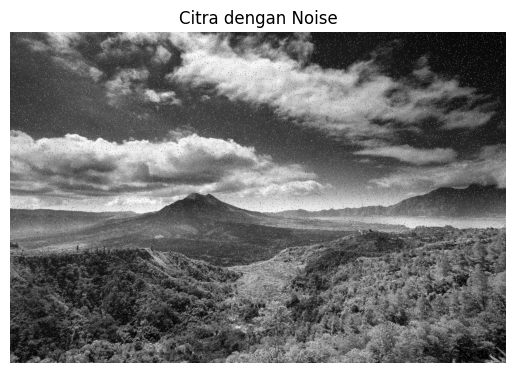

In [31]:
# 1. Ambil citra asli
image_path = 'citra.jpg'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE) # Membaca dalam grayscale agar lebih mudah dianalisis

if img is None:
    print("Error: File 'citra.jpg' tidak ditemukan. Mohon upload file terlebih dahulu.")
else:
    # 2. Tambahkan Salt-Pepper noise p=0.03
    # mode='s&p', amount=0.03
    noise_img = random_noise(img, mode='s&p', amount=0.03)

    # random_noise mengembalikan float [0,1], kita kembalikan ke [0,255] uint8
    noise_img = np.array(255 * noise_img, dtype='uint8')

    print("Noise Salt & Pepper berhasil ditambahkan.")

    # Tampilkan preview kecil
    plt.imshow(noise_img, cmap='gray')
    plt.title("Citra dengan Noise")
    plt.axis('off')
    plt.show()

In [29]:
def contraharmonic_mean_filter(img, size, Q):
    # Konversi ke float agar tidak overflow saat dipangkatkan
    img_float = np.float64(img)
    # Tambahkan epsilon kecil untuk menghindari pembagian dengan nol
    img_float = np.where(img_float == 0, 1e-5, img_float)

    # Kernel ukuran size x size dengan nilai 1 (box filter)
    kernel = np.ones((size, size), np.float64)

    # Rumus: Sum(f^(Q+1)) / Sum(f^Q)
    numerator = cv2.filter2D(np.power(img_float, Q + 1), -1, kernel)
    denominator = cv2.filter2D(np.power(img_float, Q), -1, kernel)

    # Hindari pembagian nol
    denominator = np.where(denominator == 0, 1e-5, denominator)

    result = numerator / denominator

    # Clip nilai agar tetap di range 0-255 dan kembalikan ke uint8
    result = np.clip(result, 0, 255)
    return np.uint8(result)

# Proses Filtering
kernel_size = 3

# a. Median Filter
median_filtered = cv2.medianBlur(noise_img, kernel_size)

# b. Mean Filter (Average Blur)
mean_filtered = cv2.blur(noise_img, (kernel_size, kernel_size))

# c. Contraharmonic Filter Q = 1.5
contra_pos = contraharmonic_mean_filter(noise_img, kernel_size, Q=1.5)

# d. Contraharmonic Filter Q = -1.5
contra_neg = contraharmonic_mean_filter(noise_img, kernel_size, Q=-1.5)

print("Semua filter telah diterapkan.")

Semua filter telah diterapkan.


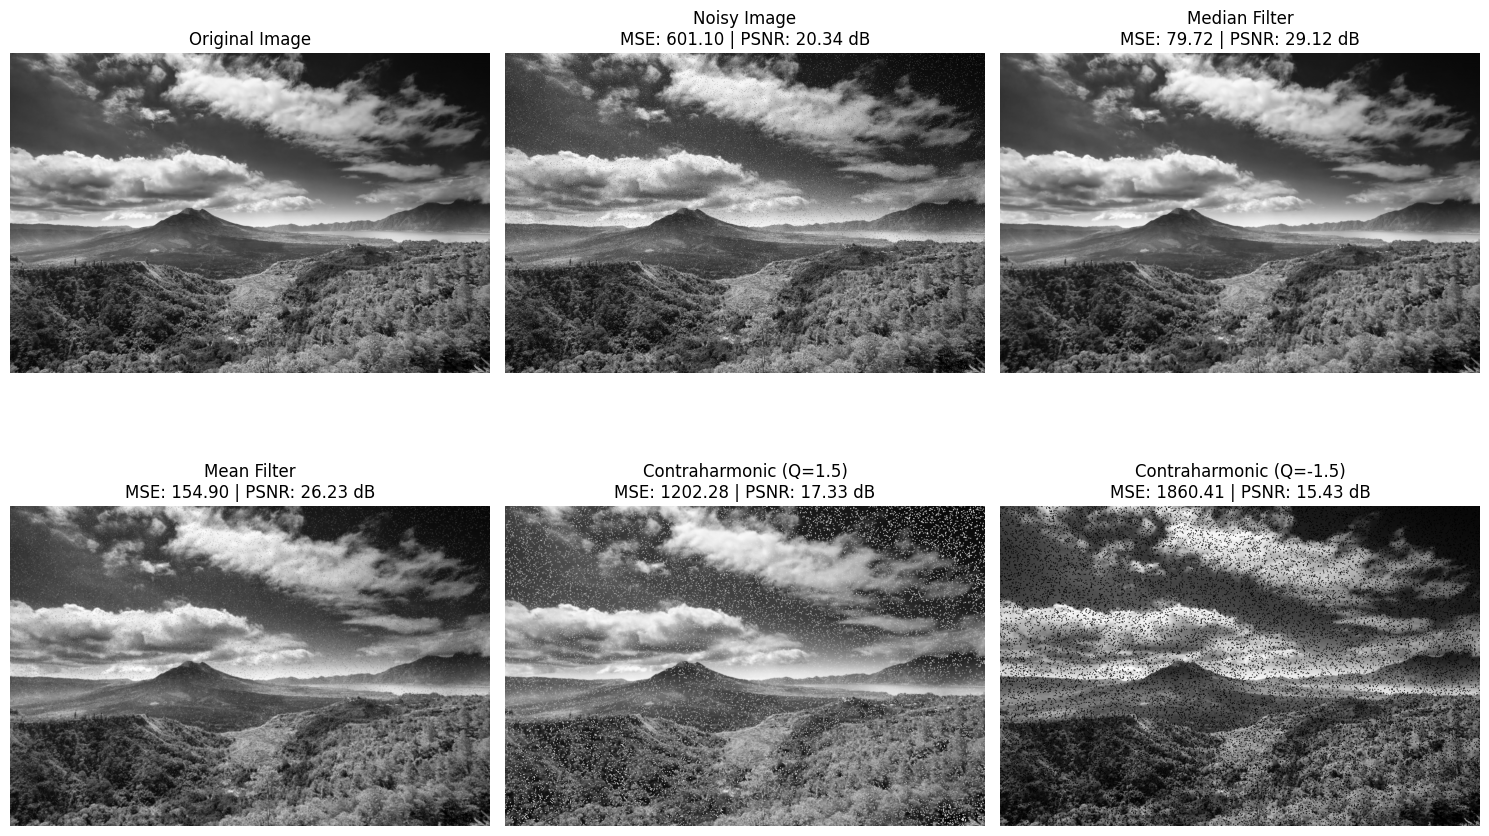


--- Perbandingan Kuantitatif ---
Metode                    | MSE (Rendah lebih baik)   | PSNR (Tinggi lebih baik) 
--------------------------------------------------------------------------------
Noisy Image               | 601.1020                  | 20.3413                  
Median Filter             | 79.7188                   | 29.1152                  
Mean Filter               | 154.8989                  | 26.2303                  
Contraharmonic (Q=1.5)    | 1202.2774                 | 17.3308                  
Contraharmonic (Q=-1.5)   | 1860.4057                 | 15.4347                  


In [30]:
# Hitung MSE dan PSNR untuk setiap metode
methods = [
    ("Noisy Image", noise_img),
    ("Median Filter", median_filtered),
    ("Mean Filter", mean_filtered),
    ("Contraharmonic (Q=1.5)", contra_pos),
    ("Contraharmonic (Q=-1.5)", contra_neg)
]

results = []
for name, processed_img in methods:
    mse_val, psnr_val = calculate_metrics(img, processed_img)
    results.append((name, processed_img, mse_val, psnr_val))

# Visualisasi
plt.figure(figsize=(15, 10))

# Plot Asli
plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

# Plot Hasil Filter
for i, (name, p_img, mse, psnr) in enumerate(results):
    plt.subplot(2, 3, i + 2)
    plt.imshow(p_img, cmap='gray')
    plt.title(f"{name}\nMSE: {mse:.2f} | PSNR: {psnr:.2f} dB")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Print Tabel Text
print("\n--- Perbandingan Kuantitatif ---")
print(f"{'Metode':<25} | {'MSE (Rendah lebih baik)':<25} | {'PSNR (Tinggi lebih baik)':<25}")
print("-" * 80)
for name, _, mse, psnr in results:
    print(f"{name:<25} | {mse:<25.4f} | {psnr:<25.4f}")